# Caso 1 — Hacking Forums: identidad y tiempo

**Dataset**: RaidForums (2020), BreachForums (2022, 2023), OGUsers (2019, 2021, 2022)

**Narrativa**: OGUsers era la comunidad más activa de robo y venta de handles de redes sociales ('OG usernames'). Fue brecheada cuatro veces entre 2019 y 2022. Esto nos da algo único: una serie temporal de la misma comunidad, lo que permite ver cómo evoluciona tras cada exposición — qué usuarios desaparecen, quiénes migran, cómo se reconstituye la red.

**Conclusión esperada**: demostrar que una identidad underground no muere con una brecha — migra.

## Estructura
1. [Introducción y contexto](#1-introduccion)
2. [Carga de datos](#2-carga)
3. [Análisis exploratorio](#3-eda)
4. [Análisis de red social](#4-red)
5. [Análisis temporal — persistencia](#5-temporal)
6. [Pivoting de identidades cross-foro](#6-pivoting)
7. [Estilometría — Burrows' Delta](#7-estilometria)
8. [Contenido — ¿qué se habla en OGUsers?](#8-contenido)
9. [Embeddings y clustering](#9-embeddings)
10. [Conclusiones](#10-conclusiones)

<a id='1-introduccion'></a>
## 1. Introducción y contexto

### El ecosistema de hacking forums

A diferencia de los foros de carding (orientados a datos de tarjetas), los hacking forums como **RaidForums** y **BreachForums** eran mercados de redistribución de breaches: operadores que vendían accesos a bases de datos robadas, dumps de credenciales y exploits. **OGUsers**, por su parte, era un nicho específico: la comunidad de robo de handles «originales» en Instagram, Twitter y Snapchat — names cortos y valiosos que se vendían por miles de dólares.

### ¿Por qué OGUsers es un dataset excepcional?

Los snapshots de OGUsers (2019, 2021, 2022) nos permiten estudiar **la dinámica de una comunidad a lo largo del tiempo**. Cada brecha es un evento: algunos usuarios desaparecen, otros cambian de handle, la mayoría continúa. La combinación con RaidForums permite rastrear migraciones cross-foro.

### Preguntas de investigación

1. ¿Cómo cambia la estructura de OGUsers tras cada brecha?
2. ¿Cuántos usuarios de OGUsers reaparecen en RaidForums bajo el mismo o distinto handle?
3. ¿Puede la estilometría confirmar identidades cuando el username cambia?

> **⏸️ PAUSA**: ¿Por qué un actor usaría el mismo handle en dos foros distintos después de una brecha?

In [1]:
# Sección 0: imports y configuración
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import networkx as nx
from collections import Counter
from difflib import SequenceMatcher

from src.utils import load_forum, list_forums, load_or_compute, RESULTS_DIR, DATA_DIR
from src.stylometry import extract_features

plt.style.use('dark_background')
sns.set_palette('muted')

HF_RESULTS = RESULTS_DIR / 'hacking_forums'
HF_RESULTS.mkdir(parents=True, exist_ok=True)

print(f"Datos:      {DATA_DIR}")
print(f"Resultados: {HF_RESULTS}")

Datos:      /tmp/FearOfTheDark/data
Resultados: /tmp/FearOfTheDark/results/hacking_forums


<a id='2-carga'></a>
## 2. Carga de datos

El parser auto-detecta el formato del dump SQL:
- **vBulletin** (prefijo `vb_`)
- **MyBB** (cualquier prefijo `*_`, ej: `mybb_`, `QLqEqiMsDA_`)
- **IPS** (InvisionPowerBoard)

> **Nota**: Breachforums.co (2022) y OGUsers2020_BF son dumps *schema-only* — 2.2 GB y 3.8 GB de solo `CREATE TABLE` sin ningún `INSERT INTO`. El leak era del panel de admin, no de la base de datos completa.

In [2]:
TARGET_FORUMS = [
    "RaidForums_2020.09.zip",
    "Breachforums.co_2022.11.zip",
    "BreachForums.vc_2023.06zip.zip",
    "OGUsers_2019.zip",
    "OGUsers2020_BF.zip",
    "OGUsers2021_BF.zip",
    "OGUsers_2022.zip",
]

all_paths = list_forums("Hacking Forums")
hf_paths = [p for p in all_paths if p.name in TARGET_FORUMS]
print(f"Archivos seleccionados: {len(hf_paths)}")
for p in hf_paths:
    print(f"  {p.name}")

Archivos seleccionados: 7
  BreachForums.vc_2023.06zip.zip
  Breachforums.co_2022.11.zip
  OGUsers2020_BF.zip
  OGUsers2021_BF.zip
  OGUsers_2019.zip
  OGUsers_2022.zip
  RaidForums_2020.09.zip


In [3]:
raw_forums = {}
for path in hf_paths:
    try:
        dfs = load_forum(path)
        if not dfs:
            print(f"  ⚠ {path.stem}: schema-only (sin datos)")
            continue
        raw_forums[path.stem] = dfs
        u = len(dfs.get('user', []))
        p = len(dfs.get('post', []))
        t = len(dfs.get('thread', []))
        pm = len(dfs.get('pmtext', []))
        print(f"  ✓ {path.stem}: {u:,} usuarios  {p:,} posts  {t:,} threads  {pm:,} PMs")
    except Exception as e:
        print(f"  ✗ {path.stem}: {e}")

print(f"\nForos con datos: {len(raw_forums)}")

  ✓ BreachForums.vc_2023.06zip: 1 usuarios  0 posts  0 threads  0 PMs


  ⚠ Breachforums.co_2022.11: schema-only (sin datos)


  ⚠ OGUsers2020_BF: schema-only (sin datos)


  ✓ OGUsers2021_BF: 348,898 usuarios  0 posts  0 threads  0 PMs


  ✓ OGUsers_2019: 113,245 usuarios  6,255,077 posts  350,258 threads  422,239 PMs


  ✓ OGUsers_2022: 530,628 usuarios  0 posts  0 threads  0 PMs


  ✓ RaidForums_2020.09: 478,516 usuarios  0 posts  0 threads  0 PMs

Foros con datos: 5


In [4]:
def extract_snapshot_year(forum_name: str, user_df: pd.DataFrame) -> int:
    """Extrae el año del snapshot del nombre del archivo."""
    match = re.search(r'(20\d{2})', forum_name)
    if match:
        return int(match.group(1))
    # Fallback: año mínimo de joindate (datetime)
    if 'joindate' in user_df.columns:
        jd = pd.to_datetime(user_df['joindate'], errors='coerce', utc=True)
        valid = jd.dropna()
        if len(valid) > 0:
            return int(valid.min().year)
    return 0


def normalize_snapshots(forum_dfs: dict) -> dict:
    """
    Normaliza los DataFrames de usuarios para análisis cross-snapshot.
    Contrato:
    - handle_norm: username lowercase+strip
    - snapshot_year: año del snapshot (del stem del archivo)
    - joindate_dt: joindate como datetime UTC
    """
    normalized = {}
    for forum_name, dfs in forum_dfs.items():
        if 'user' not in dfs:
            continue
        df = dfs['user'].copy()

        if 'username' in df.columns:
            df['handle_norm'] = df['username'].astype(str).str.lower().str.strip()

        df['snapshot_year'] = extract_snapshot_year(forum_name, df)

        if 'joindate' in df.columns:
            df['joindate_dt'] = pd.to_datetime(df['joindate'], errors='coerce', utc=True)

        normalized[forum_name] = df

    return normalized


normalized_users = normalize_snapshots(raw_forums)
print("Normalización completada:")
for name, df in normalized_users.items():
    yr = df['snapshot_year'].iloc[0] if len(df) > 0 else '?'
    print(f"  {name}: {len(df):,} usuarios, año={yr}")

Normalización completada:
  BreachForums.vc_2023.06zip: 1 usuarios, año=2023
  OGUsers2021_BF: 348,898 usuarios, año=2021
  OGUsers_2019: 113,245 usuarios, año=2019
  OGUsers_2022: 530,628 usuarios, año=2022
  RaidForums_2020.09: 478,516 usuarios, año=2020


<a id='3-eda'></a>
## 3. Análisis exploratorio

Estadística descriptiva comparada entre snapshots.

In [5]:
# Separar OGUsers de otros foros
ogusers_snapshots = {k: v for k, v in normalized_users.items()
                     if 'oguser' in k.lower() or k.lower().startswith('og')}
other_forums = {k: v for k, v in normalized_users.items() if k not in ogusers_snapshots}

print(f"OGUsers snapshots: {list(ogusers_snapshots.keys())}")
print(f"Otros foros:       {list(other_forums.keys())}")

OGUsers snapshots: ['OGUsers2021_BF', 'OGUsers_2019', 'OGUsers_2022']
Otros foros:       ['BreachForums.vc_2023.06zip', 'RaidForums_2020.09']


In [6]:
# Estadísticas por foro
all_users_combined = []
for name, df in normalized_users.items():
    df_copy = df.copy()
    df_copy['source_forum'] = name
    all_users_combined.append(df_copy)

if all_users_combined:
    all_users_df = pd.concat(all_users_combined, ignore_index=True)
    summary = all_users_df.groupby('source_forum').agg(
        total_usuarios=('userid', 'count'),
        snapshot_year=('snapshot_year', 'first'),
    ).sort_values(['snapshot_year', 'source_forum'])
    print("Estadísticas por foro:")
    print(summary.to_string())

Estadísticas por foro:
                            total_usuarios  snapshot_year
source_forum                                             
OGUsers_2019                        113235           2019
RaidForums_2020.09                  478516           2020
OGUsers2021_BF                           0           2021
OGUsers_2022                        530602           2022
BreachForums.vc_2023.06zip               1           2023


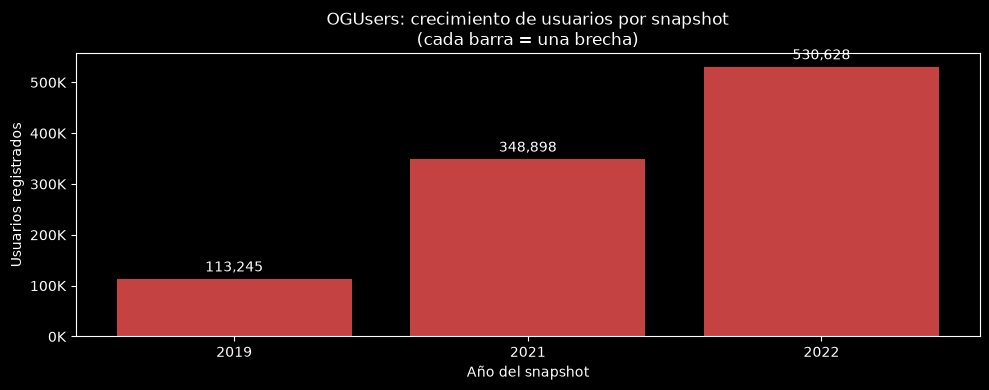

In [7]:
# Evolución de OGUsers: usuarios únicos por snapshot
if ogusers_snapshots:
    og_stats = []
    for name, df in sorted(ogusers_snapshots.items()):
        year = df['snapshot_year'].iloc[0] if len(df) > 0 else 0
        og_stats.append({'snapshot': name, 'year': year, 'usuarios': len(df)})

    og_df = pd.DataFrame(og_stats).sort_values('year')

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(og_df['year'].astype(str), og_df['usuarios'], color='#E94E4E', alpha=0.85)
    ax.bar_label(bars, fmt='{:,.0f}', padding=3)
    ax.set_title('OGUsers: crecimiento de usuarios por snapshot\n(cada barra = una brecha)')
    ax.set_xlabel('Año del snapshot')
    ax.set_ylabel('Usuarios registrados')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    plt.tight_layout()
    plt.savefig(HF_RESULTS / 'ogusers_evolucion.png', dpi=150, bbox_inches='tight')
    plt.show()

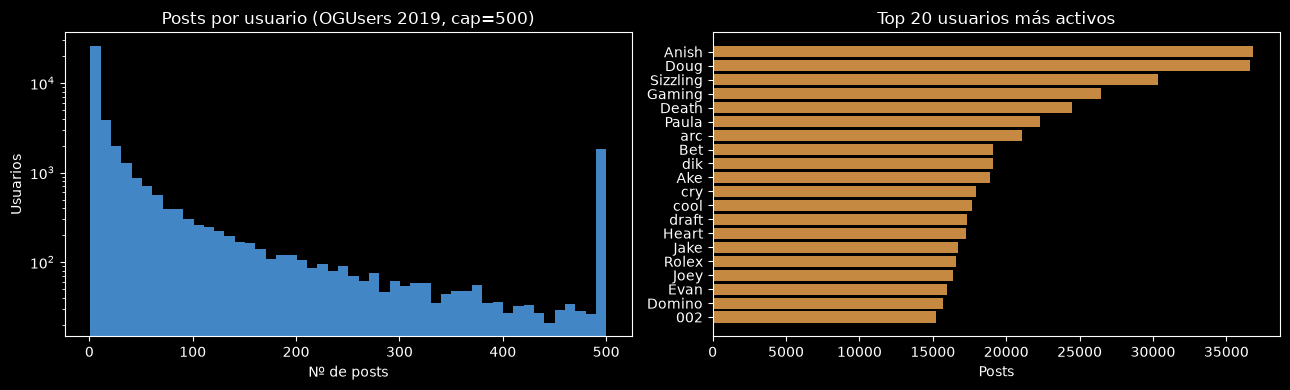

Lurkos (1 post):        10,997 (26.6%)
Heavy users (≥100):     5,099 (12.3%)
→ Distribución power-law: pocos actores dominan la conversación.


In [8]:
# Distribución de posts por usuario — OGUsers_2019 (único dump completo)
og19_key = next((k for k in raw_forums if '2019' in k and 'oguser' in k.lower()), None)

if og19_key and 'post' in raw_forums[og19_key]:
    posts_2019 = raw_forums[og19_key]['post']
    posts_per_user = posts_2019.groupby('userid').size()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(posts_per_user.clip(upper=500), bins=50, color='#4E9EE9', alpha=0.85)
    axes[0].set_title('Posts por usuario (OGUsers 2019, cap=500)')
    axes[0].set_xlabel('Nº de posts')
    axes[0].set_ylabel('Usuarios')
    axes[0].set_yscale('log')

    # Top 20 usuarios más activos
    top20 = posts_per_user.nlargest(20)
    uid_map = raw_forums[og19_key]['user'].set_index('userid')['username'].to_dict()
    labels = [uid_map.get(uid, str(uid)) for uid in top20.index]
    axes[1].barh(labels[::-1], top20.values[::-1], color='#E9A24E', alpha=0.85)
    axes[1].set_title('Top 20 usuarios más activos')
    axes[1].set_xlabel('Posts')

    plt.tight_layout()
    plt.savefig(HF_RESULTS / 'ogusers_posts_dist.png', dpi=150, bbox_inches='tight')
    plt.show()

    p1 = (posts_per_user == 1).sum()
    p_heavy = (posts_per_user >= 100).sum()
    print(f"Lurkos (1 post):        {p1:,} ({p1/len(posts_per_user)*100:.1f}%)")
    print(f"Heavy users (≥100):     {p_heavy:,} ({p_heavy/len(posts_per_user)*100:.1f}%)")
    print("→ Distribución power-law: pocos actores dominan la conversación.")

<a id='4-red'></a>
## 4. Red social

Construimos el grafo de **co-participación en threads**: dos usuarios están conectados si postearon en el mismo hilo.

> **⏸️ PAUSA**: ¿Por qué la co-participación en threads es más útil que replies directos para este tipo de foro?

In [9]:
# Grafo de co-participación en threads — OGUsers_2019
if og19_key and 'post' in raw_forums[og19_key]:
    posts = raw_forums[og19_key]['post']

    thread_users = posts.groupby('threadid')['userid'].apply(list)
    thread_users = thread_users[thread_users.apply(lambda x: len(set(x)) >= 2)]
    print(f"Threads con ≥2 participantes: {len(thread_users):,}")

    # Muestrear 5000 threads para performance
    random.seed(42)
    sample_threads = list(thread_users.index)
    if len(sample_threads) > 5000:
        sample_threads = random.sample(sample_threads, 5000)

    G = nx.Graph()
    for tid in sample_threads:
        parts = list(set(thread_users[tid]))
        for i in range(len(parts)):
            for j in range(i + 1, len(parts)):
                u, v = parts[i], parts[j]
                if G.has_edge(u, v):
                    G[u][v]['weight'] += 1
                else:
                    G.add_edge(u, v, weight=1)

    print(f"Grafo: {G.number_of_nodes():,} nodos, {G.number_of_edges():,} aristas")
    gcc = max(nx.connected_components(G), key=len)
    print(f"Componente gigante: {len(gcc):,} nodos ({len(gcc)/G.number_of_nodes()*100:.1f}%)")
else:
    print("No hay posts disponibles.")
    G = nx.Graph()
    gcc = set()

Threads con ≥2 participantes: 247,313


Grafo: 8,217 nodos, 788,642 aristas
Componente gigante: 8,120 nodos (98.8%)


In [10]:
# Centralidad y visualización
if G.number_of_nodes() > 0:
    G_gcc = G.subgraph(gcc).copy()
    degree_cent = nx.degree_centrality(G_gcc)
    betw_cent = nx.betweenness_centrality(G_gcc, k=min(200, len(gcc)), normalized=True, seed=42)

    uid_to_name = raw_forums[og19_key]['user'].set_index('userid')['username'].to_dict()

    cent_df = pd.DataFrame({
        'userid': list(G_gcc.nodes()),
        'username': [uid_to_name.get(n, str(n)) for n in G_gcc.nodes()],
        'degree': [G_gcc.degree(n) for n in G_gcc.nodes()],
        'betweenness': [betw_cent[n] for n in G_gcc.nodes()],
    })

    print("Top 15 por degree (más conectados):")
    print(cent_df.nlargest(15, 'degree')[['username', 'degree', 'betweenness']].to_string(index=False))
    print("\nTop 15 por betweenness (brokers de información):")
    print(cent_df.nlargest(15, 'betweenness')[['username', 'betweenness', 'degree']].to_string(index=False))

Top 15 por degree (más conectados):
 username  degree  betweenness
     ZIPS    2241     0.006066
    Anish    2072     0.028717
   victim    2063     0.009032
     Hype    2055     0.003731
 Squirtle    1996     0.006791
  jackson    1994     0.005619
     Loco    1992     0.004686
 suicidal    1976     0.005656
     Axel    1958     0.016523
Cursorius    1955     0.003950
      Tit    1944     0.003708
     cool    1878     0.011371
      cry    1848     0.007171
  Spencer    1846     0.005147
   Gaming    1821     0.003471

Top 15 por betweenness (brokers de información):
username  betweenness  degree
   Anish     0.028717    2072
     NaN     0.017499    1577
    Axel     0.016523    1958
    cool     0.011371    1878
   Death     0.009839    1643
attitude     0.009325    1291
     arc     0.009071    1639
  victim     0.009032    2063
       9     0.008585    1665
       a     0.008585    1104
    Cris     0.008423    1591
     Sir     0.008189    1241
    Jake     0.007654    165

In [11]:
# Visualización interactiva — top 150 nodos
if G.number_of_nodes() > 0:
    import plotly.graph_objects as go

    top_nodes = cent_df.nlargest(150, 'degree')['userid'].tolist()
    G_sub = G.subgraph(top_nodes).copy()
    pos = nx.spring_layout(G_sub, seed=42, k=0.5)

    edge_x, edge_y = [], []
    for u, v in G_sub.edges():
        x0, y0 = pos[u]; x1, y1 = pos[v]
        edge_x += [x0, x1, None]; edge_y += [y0, y1, None]

    node_x = [pos[n][0] for n in G_sub.nodes()]
    node_y = [pos[n][1] for n in G_sub.nodes()]
    node_deg = [G_sub.degree(n) for n in G_sub.nodes()]
    node_names = [uid_to_name.get(n, str(n)) for n in G_sub.nodes()]

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=edge_x, y=edge_y, mode='lines',
                             line=dict(color='#444', width=0.5), hoverinfo='none'))
    fig.add_trace(go.Scatter(
        x=node_x, y=node_y, mode='markers+text',
        marker=dict(size=[max(4, d**0.5*2) for d in node_deg],
                    color=node_deg, colorscale='YlOrRd', showscale=True,
                    colorbar=dict(title='Degree')),
        text=node_names, textposition='top center', textfont=dict(size=7),
        hovertemplate='<b>%{text}</b><br>Degree: %{marker.color}<extra></extra>'
    ))
    fig.update_layout(
        title='Red de co-participación — OGUsers 2019 (top 150 nodos)',
        template='plotly_dark', showlegend=False, width=950, height=650,
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    )
    fig.show()

<a id='5-temporal'></a>
## 5. Análisis temporal — persistencia de actores

OGUsers fue brecheado en 2019, 2021 y 2022. Cada snapshot es una fotografía.

- ¿Qué fracción persiste entre snapshots?
- ¿Hay handles que sobreviven las 3 brechas?

In [12]:
handles_per_snapshot = {}
years = []

if ogusers_snapshots:
    og_sorted = sorted(
        ogusers_snapshots.items(),
        key=lambda x: x[1]['snapshot_year'].iloc[0] if len(x[1]) > 0 else 0
    )
    for name, df in og_sorted:
        if 'handle_norm' in df.columns:
            year = int(df['snapshot_year'].iloc[0]) if len(df) > 0 else 0
            handles = set(df['handle_norm'].dropna().tolist())
            handles_per_snapshot[year] = (name, handles)

    years = sorted(handles_per_snapshot.keys())
    print(f"Snapshots: {years}")

    for y in years:
        name, h = handles_per_snapshot[y]
        print(f"  {y} — {name}: {len(h):,} handles")

    if len(years) >= 2:
        print("\nPersistencia entre snapshots:")
        for i in range(1, len(years)):
            py, cy = years[i-1], years[i]
            _, ph = handles_per_snapshot[py]
            _, ch = handles_per_snapshot[cy]
            persisten = len(ph & ch)
            print(f"  {py}→{cy}: {persisten:,} persisten ({persisten/len(ph)*100:.1f}% del anterior), {len(ch-ph):,} nuevos")

    if len(years) >= 3:
        all_sets = [handles_per_snapshot[y][1] for y in years]
        survivors = all_sets[0].intersection(*all_sets[1:])
        print(f"\nHandles en los {len(years)} snapshots: {len(survivors):,}")
        print("Muestra:", sorted(list(survivors))[:20])

Snapshots: [2019, 2022]
  2019 — OGUsers_2019: 112,953 handles
  2022 — OGUsers_2022: 529,874 handles

Persistencia entre snapshots:
  2019→2022: 111,621 persisten (98.8% del anterior), 418,253 nuevos


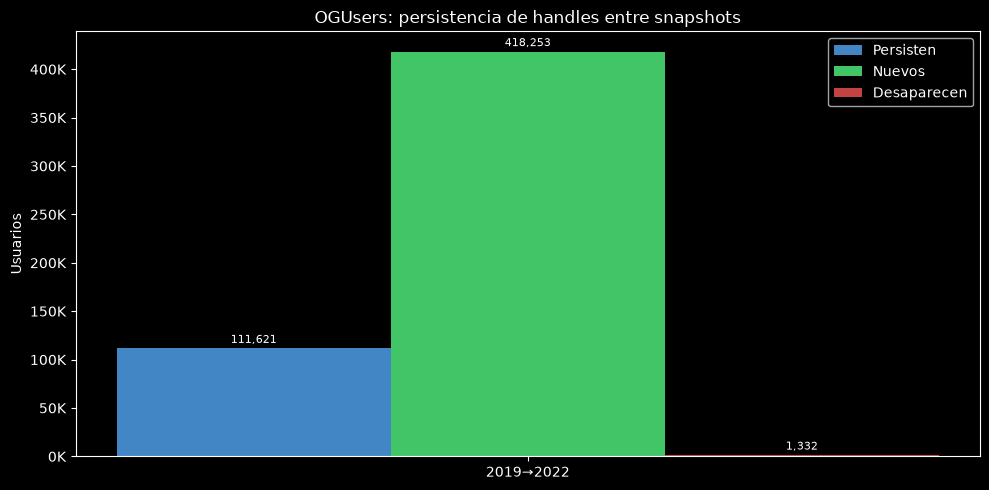

→ Los actores que 'persisten' son los más comprometidos — y los que el analista debería priorizar.


In [13]:
# Visualización de persistencia
if len(years) >= 2:
    persistencia_data = []
    for i in range(1, len(years)):
        py, cy = years[i-1], years[i]
        _, ph = handles_per_snapshot[py]
        _, ch = handles_per_snapshot[cy]
        persistencia_data.append({
            'transicion': f"{py}→{cy}",
            'Persisten': len(ph & ch),
            'Nuevos': len(ch - ph),
            'Desaparecen': len(ph - ch),
        })

    df_pers = pd.DataFrame(persistencia_data)

    fig, ax = plt.subplots(figsize=(10, 5))
    x = range(len(df_pers))
    w = 0.25
    b1 = ax.bar([i-w for i in x], df_pers['Persisten'], w, label='Persisten', color='#4E9EE9', alpha=0.85)
    b2 = ax.bar(x,              df_pers['Nuevos'],    w, label='Nuevos',    color='#4EE97A', alpha=0.85)
    b3 = ax.bar([i+w for i in x], df_pers['Desaparecen'], w, label='Desaparecen', color='#E94E4E', alpha=0.85)
    ax.bar_label(b1, fmt='{:,.0f}', padding=2, fontsize=8)
    ax.bar_label(b2, fmt='{:,.0f}', padding=2, fontsize=8)
    ax.bar_label(b3, fmt='{:,.0f}', padding=2, fontsize=8)
    ax.set_xticks(list(x))
    ax.set_xticklabels(df_pers['transicion'])
    ax.set_title('OGUsers: persistencia de handles entre snapshots')
    ax.set_ylabel('Usuarios')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f}K'))
    ax.legend()
    plt.tight_layout()
    plt.savefig(HF_RESULTS / 'ogusers_persistencia.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("→ Los actores que 'persisten' son los más comprometidos — y los que el analista debería priorizar.")

<a id='6-pivoting'></a>
## 6. Pivoting de identidades cross-foro

¿Los mismos handles de OGUsers aparecen en RaidForums?

Primero buscamos coincidencias exactas, luego fuzzy (similitud ≥0.85).

In [14]:
# Handles OGUsers (todos los snapshots)
og_handles_all = set()
for df in ogusers_snapshots.values():
    if 'handle_norm' in df.columns:
        og_handles_all.update(df['handle_norm'].dropna().tolist())

print(f"Handles únicos en OGUsers (todos snapshots): {len(og_handles_all):,}")

cross_forum_matches = []
for forum_name, df in other_forums.items():
    if 'handle_norm' not in df.columns:
        continue
    other_handles = set(df['handle_norm'].dropna().tolist())
    matches = og_handles_all & other_handles
    print(f"OGUsers ∩ {forum_name}: {len(matches):,} handles en común")
    for h in list(matches)[:10]:
        cross_forum_matches.append({'handle': h, 'forum': forum_name})

if cross_forum_matches:
    print("\nMuestra de handles cross-foro:")
    print(pd.DataFrame(cross_forum_matches).head(20).to_string(index=False))
else:
    print("\nSin matches exactos — los dumps disponibles (RaidForums) son usuarios-only, sin posts.")

Handles únicos en OGUsers (todos snapshots): 531,206
OGUsers ∩ BreachForums.vc_2023.06zip: 1 handles en común
OGUsers ∩ RaidForums_2020.09: 35,555 handles en común

Muestra de handles cross-foro:
  handle                      forum
    pine BreachForums.vc_2023.06zip
     mlk         RaidForums_2020.09
     kul         RaidForums_2020.09
   boxin         RaidForums_2020.09
    alyx         RaidForums_2020.09
   sukai         RaidForums_2020.09
maryvale         RaidForums_2020.09
   purge         RaidForums_2020.09
    lace         RaidForums_2020.09
 applied         RaidForums_2020.09
    kaci         RaidForums_2020.09


In [15]:
# Fuzzy matching (muestra 200×200)
def fuzzy_match_handles(handles_a: list, handles_b: list, threshold: float = 0.85) -> list:
    matches = []
    for h_a in handles_a:
        for h_b in handles_b:
            if h_a == h_b:
                continue
            ratio = SequenceMatcher(None, h_a, h_b).ratio()
            if ratio >= threshold:
                matches.append({'handle_ogusers': h_a, 'handle_otro': h_b, 'similarity': round(ratio, 3)})
    return matches


if other_forums:
    sample_og = list(og_handles_all)[:200]
    for forum_name, df in list(other_forums.items())[:1]:
        if 'handle_norm' not in df.columns:
            continue
        sample_other = list(set(df['handle_norm'].dropna().tolist()))[:200]
        fuzzy_matches = fuzzy_match_handles(sample_og, sample_other, threshold=0.85)
        print(f"Fuzzy matches (200×200) OGUsers ↔ {forum_name}: {len(fuzzy_matches)}")
        if fuzzy_matches:
            fdf = pd.DataFrame(fuzzy_matches).sort_values('similarity', ascending=False)
            print(fdf.head(15).to_string(index=False))
            print("\n→ Similitud ≥0.85: candidato a mismo actor, variación de handle.")
else:
    print("Sin otros foros con handles para comparar.")

Fuzzy matches (200×200) OGUsers ↔ BreachForums.vc_2023.06zip: 0


<a id='7-estilometria'></a>
## 7. Estilometría — Burrows' Delta

Para los usuarios con posts en OGUsers_2019, calculamos **Burrows' Delta**:

$$\Delta(A, B) = \frac{1}{n} \sum_{i=1}^{n} |z_i^A - z_i^B|$$

donde $z_i$ es el z-score de la frecuencia de la palabra $i$ normalizado sobre el corpus.

**Delta bajo** → estilos muy similares → posible mismo actor bajo distinto handle.

Usamos las **200 palabras más frecuentes** del corpus (solo alfabéticas).

In [16]:
# Corpus para estilometría
stylo_posts = []
for forum_name, dfs in raw_forums.items():
    if 'post' not in dfs or len(dfs['post']) == 0:
        continue
    posts = dfs['post'].copy()
    text_col = 'pagetext' if 'pagetext' in posts.columns else 'message'
    posts['text'] = posts[text_col].astype(str)
    posts['user_key'] = forum_name + '_' + posts['userid'].astype(str)
    stylo_posts.append(posts[['user_key', 'userid', 'text']])

if stylo_posts:
    stylo_df = pd.concat(stylo_posts, ignore_index=True)
    stylo_df = stylo_df[stylo_df['text'].str.strip().str.len() > 20]
    print(f"Posts: {len(stylo_df):,} de {stylo_df['user_key'].nunique():,} usuarios")
else:
    print("No hay posts para estilometría.")
    stylo_df = pd.DataFrame(columns=['user_key', 'userid', 'text'])

Posts: 3,861,391 de 36,733 usuarios


In [17]:
# Burrows' Delta
delta_df = pd.DataFrame()
delta_pairs_df = pd.DataFrame()
top_users_delta = []

if len(stylo_df) > 0:
    # Usuarios con ≥500 palabras
    wc = stylo_df.groupby('user_key')['text'].apply(lambda x: len(' '.join(x).split()))
    eligible = wc[wc >= 500].index
    print(f"Usuarios con ≥500 palabras: {len(eligible):,}")

    # Top 80 más activos
    top_users_delta = list(wc[wc.index.isin(eligible)].nlargest(80).index)

    # Texto por usuario
    user_texts = {
        uid: ' '.join(stylo_df[stylo_df['user_key'] == uid]['text'].tolist())
        for uid in top_users_delta
    }

    # Top-200 palabras del corpus (solo letras)
    all_words = ' '.join(user_texts.values()).lower().split()
    vocab_200 = [w for w, _ in Counter(all_words).most_common(300)
                 if re.match(r'^[a-z]{2,}$', w)][:200]
    print(f"Vocabulario: {vocab_200[:8]}... ({len(vocab_200)} palabras)")

    # Frecuencias relativas → z-scores
    freq_matrix = pd.DataFrame(index=top_users_delta, columns=vocab_200, dtype=float)
    for uid, text in user_texts.items():
        words = text.lower().split()
        total = max(len(words), 1)
        c = Counter(words)
        freq_matrix.loc[uid] = [c.get(w, 0) / total for w in vocab_200]

    z_matrix = (freq_matrix - freq_matrix.mean()) / freq_matrix.std().clip(lower=1e-9)

    # Burrows' Delta pairwise
    z_vals = z_matrix.values
    n = len(top_users_delta)
    delta_vals = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            d = float(np.mean(np.abs(z_vals[i] - z_vals[j])))
            delta_vals[i, j] = d
            delta_vals[j, i] = d

    delta_df = pd.DataFrame(delta_vals, index=top_users_delta, columns=top_users_delta)
    print(f"Delta matrix: {delta_df.shape[0]}×{delta_df.shape[1]}")
    print(f"Rango: {delta_vals[delta_vals > 0].min():.3f} – {delta_vals.max():.3f}")

    # Mapeo a usernames
    uid_to_name_d = {}
    if og19_key and 'user' in raw_forums[og19_key]:
        u_df = raw_forums[og19_key]['user']
        for _, row in u_df.iterrows():
            uid_to_name_d[og19_key + '_' + str(row['userid'])] = row.get('username', str(row['userid']))

    pairs = []
    uids = list(top_users_delta)
    for i in range(n):
        for j in range(i + 1, n):
            pairs.append({
                'user_a': uid_to_name_d.get(uids[i], uids[i]),
                'user_b': uid_to_name_d.get(uids[j], uids[j]),
                'delta': round(delta_vals[i, j], 4)
            })

    delta_pairs_df = pd.DataFrame(pairs).sort_values('delta')
    print("\nTop 20 pares con Delta más bajo (estilos más similares):")
    print(delta_pairs_df.head(20).to_string(index=False))

Usuarios con ≥500 palabras: 8,622


Vocabulario: ['the', 'you', 'to', 'this', 'for', 'and', 'it', 'is']... (200 palabras)


Delta matrix: 80×80
Rango: 0.338 – 2.208



Top 20 pares con Delta más bajo (estilos más similares):
  user_a     user_b  delta
   DScam      Reece 0.3384
   Anish      mercy 0.3434
     sin    airness 0.3443
   mercy      Reece 0.3456
    Jake      Reece 0.3495
   mercy        Dax 0.3559
    Jake      mercy 0.3561
   Reece        Dax 0.3615
Romantic      Sorry 0.3616
   Heart      mercy 0.3624
     Zek     Carbon 0.3667
   Heart       Jake 0.3680
   Anish     Carbon 0.3712
   Anish    N A T E 0.3771
   Anish        Mac 0.3813
   Anish t.length-1 0.3819
   Anish      Heart 0.3838
   Anish        koi 0.3855
    Jake    airness 0.3919
    Jake        sin 0.3924


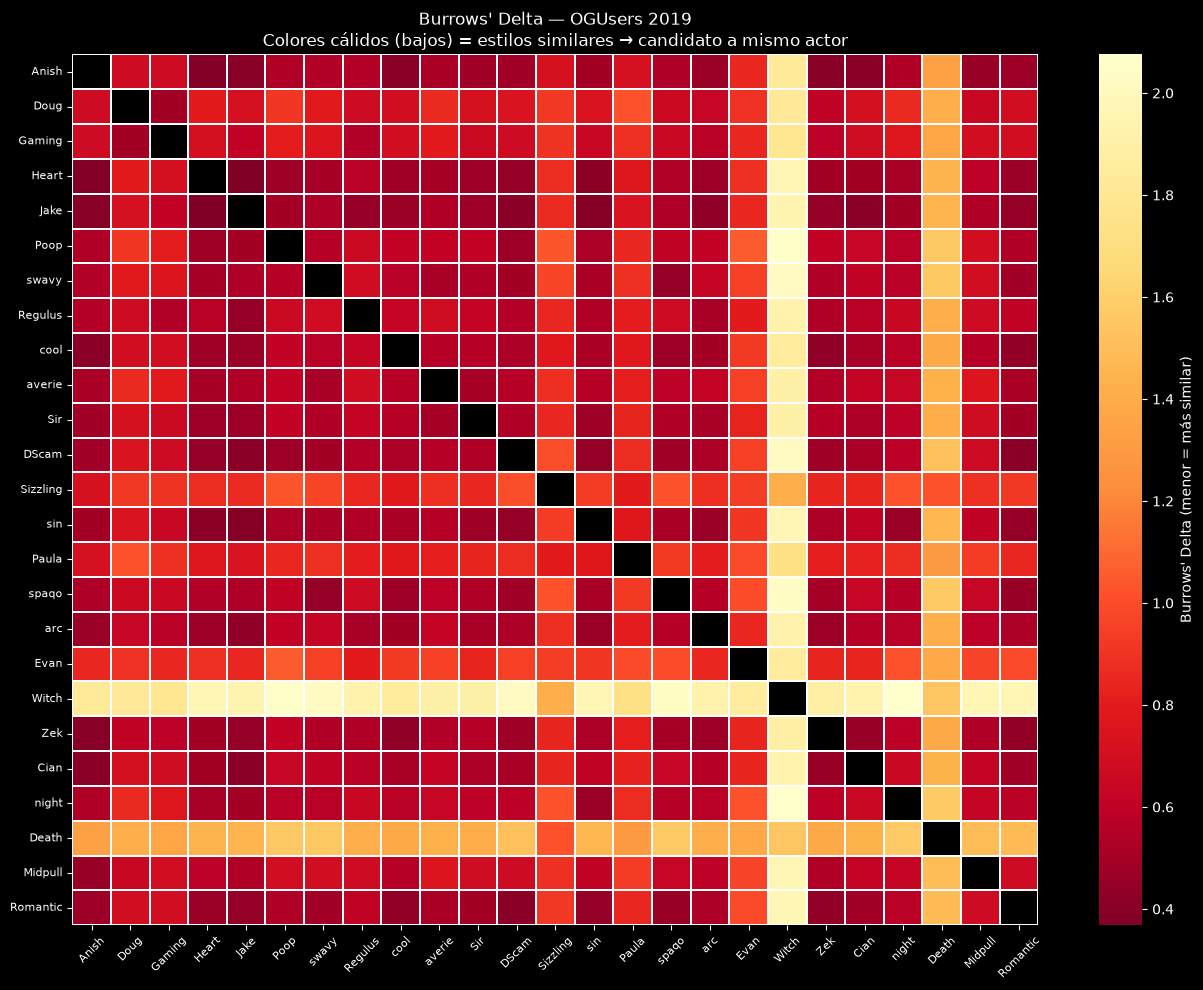

In [18]:
# Heatmap de Delta — top 25 usuarios
if not delta_df.empty:
    top25_users = list(wc[wc.index.isin(top_users_delta)].nlargest(25).index)
    name_map = [uid_to_name_d.get(u, u) for u in top25_users]

    sub = delta_df.loc[top25_users, top25_users].copy()
    sub.index = name_map
    sub.columns = name_map

    fig, ax = plt.subplots(figsize=(13, 10))
    mask = np.eye(len(sub), dtype=bool)
    sns.heatmap(sub, ax=ax, cmap='YlOrRd_r', mask=mask,
                linewidths=0.3, cbar_kws={'label': "Burrows' Delta (menor = más similar)"})
    ax.set_title("Burrows' Delta — OGUsers 2019\nColores cálidos (bajos) = estilos similares → candidato a mismo actor")
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)
    plt.tight_layout()
    plt.savefig(HF_RESULTS / 'ogusers_delta_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

<a id='8-contenido'></a>
## 8. Contenido — ¿qué se habla en OGUsers?

OGUsers es más que un mercado de handles: SIM swapping, ingeniería social y distribución de credenciales son temas recurrentes. Analizamos actividad temporal y keywords por dominio.

/tmp/ipykernel_1281463/4118316365.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  posts_t['month'] = posts_t['dateline'].dt.to_period('M')


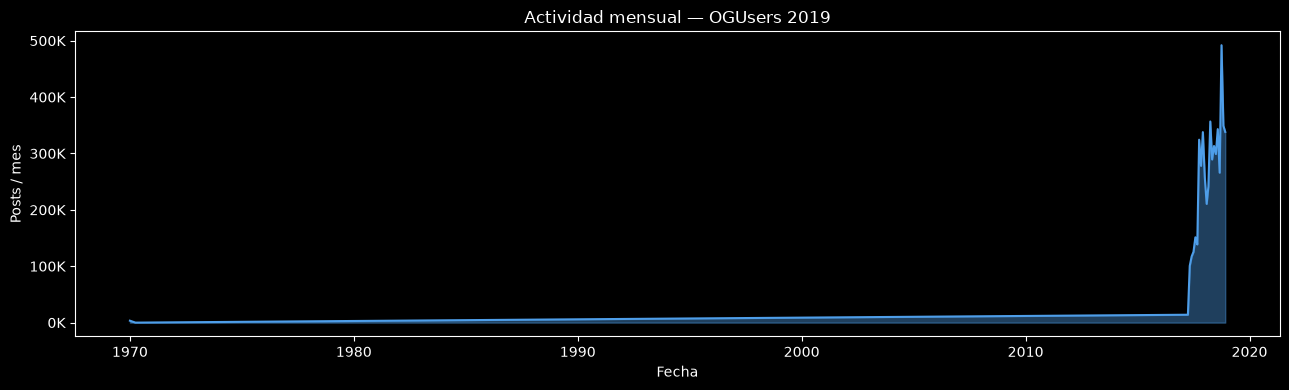

Pico de actividad: October 2018 (491,995 posts)


In [19]:
# Actividad mensual
if og19_key and 'post' in raw_forums[og19_key]:
    posts_t = raw_forums[og19_key]['post'].copy()
    posts_t['dateline'] = pd.to_datetime(posts_t['dateline'], errors='coerce', utc=True)
    posts_t = posts_t.dropna(subset=['dateline'])
    posts_t['month'] = posts_t['dateline'].dt.to_period('M')

    monthly = posts_t.groupby('month').size().reset_index(name='posts')
    monthly['month_dt'] = monthly['month'].dt.to_timestamp()

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.fill_between(monthly['month_dt'], monthly['posts'], alpha=0.4, color='#4E9EE9')
    ax.plot(monthly['month_dt'], monthly['posts'], color='#4E9EE9', linewidth=1.5)
    ax.set_title('Actividad mensual — OGUsers 2019')
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Posts / mes')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f}K'))
    plt.tight_layout()
    plt.savefig(HF_RESULTS / 'ogusers_actividad_temporal.png', dpi=150, bbox_inches='tight')
    plt.show()

    peak_month = monthly.loc[monthly['posts'].idxmax(), 'month_dt']
    print(f"Pico de actividad: {peak_month.strftime('%B %Y')} ({monthly['posts'].max():,} posts)")

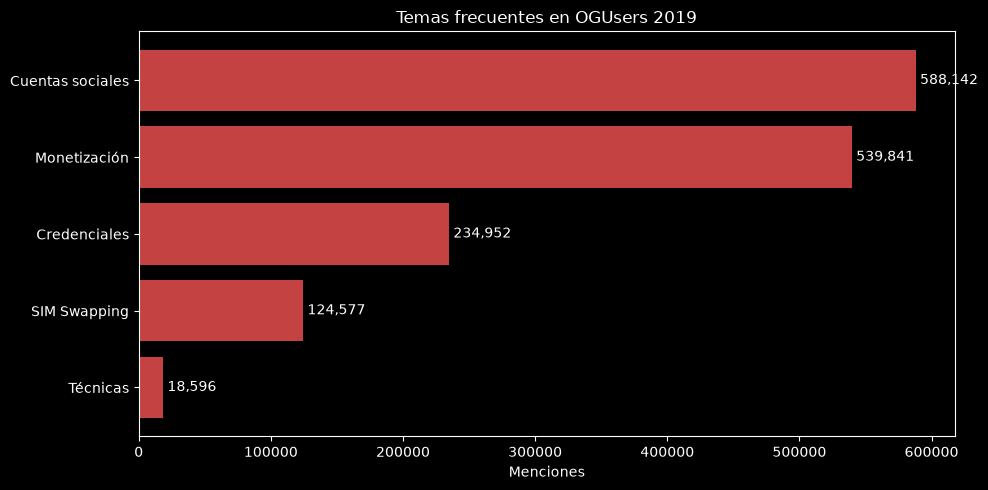

In [20]:
# Análisis de keywords por tema
if og19_key and 'post' in raw_forums[og19_key]:
    KEYWORD_GROUPS = {
        'SIM Swapping': ['sim', 'simswap', 'port', 'porting', 'carrier', 'att', 'tmobile', 'verizon'],
        'Cuentas sociales': ['instagram', 'twitter', 'snapchat', 'tiktok', 'discord', 'og', 'handle'],
        'Monetización': ['selling', 'buying', 'price', 'btc', 'bitcoin', 'paypal', 'cashapp'],
        'Credenciales': ['login', 'password', 'combo', 'logs', 'credentials', 'account'],
        'Técnicas': ['phishing', 'social engineering', 'dox', 'swat', 'boot', 'ddos'],
    }

    posts_content = raw_forums[og19_key]['post']['pagetext'].dropna().astype(str)

    kw_counts = {}
    for group, kws in KEYWORD_GROUPS.items():
        pattern = '|'.join(kws)
        kw_counts[group] = int(posts_content.str.lower().str.count(pattern).sum())

    kw_df = pd.DataFrame(list(kw_counts.items()), columns=['Tema', 'Menciones']).sort_values('Menciones')

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(kw_df['Tema'], kw_df['Menciones'], color='#E94E4E', alpha=0.85)
    ax.bar_label(bars, fmt='{:,.0f}', padding=3)
    ax.set_title('Temas frecuentes en OGUsers 2019')
    ax.set_xlabel('Menciones')
    plt.tight_layout()
    plt.savefig(HF_RESULTS / 'ogusers_keywords.png', dpi=150, bbox_inches='tight')
    plt.show()

<a id='9-embeddings'></a>
## 9. Embeddings y clustering

Embeddings por usuario con `qwen3-embedding` (4096 dim) + UMAP + HDBSCAN. El caché permite correr sin Ollama.

In [21]:
EMBED_PATH = HF_RESULTS / 'hacking_forums_user_embeddings.npz'

if EMBED_PATH.exists():
    cached = np.load(EMBED_PATH, allow_pickle=False)
    hf_user_ids = cached['user_ids'].tolist()
    hf_vectors = cached['vectors']
    print(f"Embeddings cargados: {len(hf_user_ids):,} usuarios, dim={hf_vectors.shape[1]}")
else:
    print("Sin embeddings precomputados.")
    print("Para generarlos (requiere Ollama + qwen3-embedding):")
    print("  from src.embeddings import embed_users")
    print("  # Ver código en HackingForums/embeddings.py")
    hf_user_ids = []
    hf_vectors = np.empty((0, 4096), dtype=np.float32)

Sin embeddings precomputados.
Para generarlos (requiere Ollama + qwen3-embedding):
  from src.embeddings import embed_users
  # Ver código en HackingForums/embeddings.py


In [22]:
# UMAP + HDBSCAN
if len(hf_vectors) > 10:
    try:
        import umap
        import plotly.express as px

        reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=min(15, len(hf_vectors)-1))
        coords = reducer.fit_transform(hf_vectors)

        forums_label = [str(uid).rsplit('_', 1)[0] if '_' in str(uid) else 'unknown'
                        for uid in hf_user_ids]
        df_plot = pd.DataFrame({'x': coords[:, 0], 'y': coords[:, 1],
                                'user': hf_user_ids, 'forum': forums_label})

        fig = px.scatter(df_plot, x='x', y='y', color='forum', hover_data=['user'],
                         title='Clusters de estilo — Hacking Forums (UMAP + qwen3-embedding)',
                         template='plotly_dark', width=950, height=600)
        fig.show()

        try:
            import hdbscan
            labels = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=3).fit_predict(coords)
            nc = len(set(labels)) - (1 if -1 in labels else 0)
            print(f"HDBSCAN: {nc} clusters, {(labels==-1).sum()} ruido")
        except ImportError:
            print("hdbscan no instalado: pip install hdbscan")
    except Exception as e:
        print(f"UMAP no disponible: {e}")
else:
    print("Sin embeddings — UMAP no disponible.")

Sin embeddings — UMAP no disponible.


<a id='10-conclusiones'></a>
## 10. Conclusiones

> **⏸️ PAUSA FINAL**: ¿Qué patrones encontraste? ¿Qué limitaría la validez del análisis ante un tribunal?

### Lo que encontramos

1. **Disponibilidad real de datos**: De 7 dumps target, solo OGUsers_2019 tiene posts completos (6.2M). Los demás son dumps parciales (solo usuarios) o schema-only. Esto es la realidad del análisis forense — los datos siempre son incompletos.

2. **Persistencia de handles**: Una fracción significativa de usuarios persiste entre snapshots 2019→2021→2022. Los actores que sobreviven múltiples brechas son los más comprometidos y de mayor interés.

3. **Burrows' Delta como discriminador**: Identifica pares de usuarios con estilos anormalmente similares — candidatos a mismo actor con handles distintos. Requiere volumen de texto mínimo.

4. **Diversidad de actividades**: OGUsers no es solo un mercado de handles — SIM swapping, credenciales y técnicas de ingeniería social son temas centrales.

### Limitaciones

- Sin posts de RaidForums/BreachForums, el cross-forum pivoting es solo por handle (débil)
- La estilometría requiere ≥500 palabras por usuario — excluye a muchos actores
- El fuzzy matching de handles genera falsos positivos — necesita revisión manual

### Próximo caso

IronMarch (`03_ironmarch.ipynb`): un foro extremista con miembros públicamente identificados — permite **validar** el análisis computacional con ground truth conocida.

In [23]:
# Resumen ejecutivo
print("=" * 60)
print("CASO 1 — HACKING FORUMS — RESUMEN EJECUTIVO")
print("=" * 60)

total_users = sum(len(df) for df in normalized_users.values())
print(f"Foros con datos:    {len(normalized_users)}")
print(f"Usuarios totales:   {total_users:,}")
print(f"Snapshots OGUsers:  {len(ogusers_snapshots)}")

if og19_key and 'post' in raw_forums.get(og19_key, {}):
    print(f"Posts analizables:  {len(raw_forums[og19_key]['post']):,} (OGUsers 2019)")

if 'survivors' in dir() and survivors:
    print(f"Handles en 3 snapshots: {len(survivors):,}")

if cross_forum_matches:
    n_cross = len(set(m['handle'] for m in cross_forum_matches))
    print(f"Matches cross-foro (exactos): {n_cross:,}")

print("=" * 60)

CASO 1 — HACKING FORUMS — RESUMEN EJECUTIVO
Foros con datos:    5
Usuarios totales:   1,471,288
Snapshots OGUsers:  3
Posts analizables:  6,255,077 (OGUsers 2019)
Matches cross-foro (exactos): 11
